## Phase 4 — Machine Learning Development

## TrustLens: AI-Based Website Trust & Phishing Risk Analyzer

### Objective
The objective of this phase is to prepare the cleaned dataset for machine learning,
select reproducible URL-based features, train multiple classification models,
evaluate their performance, and select the final model based on evidence.

### Target
- 0 = Phishing
- 1 = Legitimate


### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

### 2. Load the Cleaned Dataset

The processed dataset created during Phase 3 is used for machine learning development.

In [2]:
df = pd.read_csv("../data/processed/PhiUSIIL_clean.csv")

print("Dataset shape:", df.shape)

Dataset shape: (235370, 60)


### 3. Verify the Processed Dataset

Before machine learning preprocessing, the processed dataset is checked again
to confirm its dimensions, missing values, and target distribution.

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nTarget distribution:")
print(df["label"].value_counts())

print("\nTarget distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)

Rows: 235370
Columns: 60

Total missing values:
0

Target distribution:
label
1    134850
0    100520
Name: count, dtype: int64

Target distribution (%):
label
1    57.292773
0    42.707227
Name: proportion, dtype: float64


### 4. Feature Selection

TrustLens Version 1 uses URL-derived features that can be reproduced when a user
provides a new URL.

The baseline model uses 24 selected features:

- 19 URL-based features from the original PhiUSIIL dataset.
- 5 URL-based features engineered during Phase 3.

Website-content features requiring live webpage fetching are excluded from the
Version 1 ML model.

Raw identifiers and derived features whose original computation cannot be
reliably reproduced are also excluded.

In [4]:
feature_cols = [
    # Original PhiUSIIL URL features
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLD",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",

    # Features engineered during Phase 3
    "NoOfDots",
    "NoOfSlashes",
    "SuspiciousKeywordCount",
    "HasHyphenInDomain",
    "PathDepth"
]

print("Number of selected features:", len(feature_cols))

Number of selected features: 24


### 5. Separate Features and Target

X contains the input features used by the machine learning models.

y contains the target label:
- 0 = Phishing
- 1 = Legitimate

In [5]:
X = df[feature_cols]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 24)
y shape: (235370,)


### 6. Verify Selected Features

In [6]:
print("Total missing values in X:", X.isnull().sum().sum())

print("\nFeature data types:")
print(X.dtypes)

Total missing values in X: 0

Feature data types:
URLLength                       int64
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
NoOfDots                        int64
NoOfSlashes                     int64
SuspiciousKeywordCount          int64
HasHyphenInDomain               int64
PathDepth                       int64
dtype: object


### 7. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Stratification is used to preserve the phishing/legitimate class distribution.

A fixed random state is used to make the split reproducible.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (188296, 24)
X_test shape: (47074, 24)
y_train shape: (188296,)
y_test shape: (47074,)

Training class distribution:
label
1    0.572928
0    0.427072
Name: proportion, dtype: float64

Testing class distribution:
label
1    0.572928
0    0.427072
Name: proportion, dtype: float64


### 9. TLD Frequency Encoding

The TLD feature is categorical and contains many unique values.
Frequency encoding is performed using only the training data to prevent
test-set information from influencing preprocessing.

In [9]:
X_train = X_train.copy()
X_test = X_test.copy()

# Learn TLD frequencies only from training data
tld_freq_map = X_train["TLD"].value_counts(normalize=True)

# Minimum training frequency used for unseen TLDs
min_freq = tld_freq_map.min()

# Apply frequency encoding
X_train["TLD_Freq"] = X_train["TLD"].map(tld_freq_map)

X_test["TLD_Freq"] = (
    X_test["TLD"]
    .map(tld_freq_map)
    .fillna(min_freq)
)

print("Unique TLDs in training:", len(tld_freq_map))
print("Minimum TLD frequency:", min_freq)

print(
    "Unseen TLD rows in test:",
    (~X_test["TLD"].isin(tld_freq_map.index)).sum()
)

print(
    "Unseen distinct TLDs in test:",
    X_test.loc[
        ~X_test["TLD"].isin(tld_freq_map.index),
        "TLD"
    ].nunique()
)

print("TLD_Freq nulls in train:",
      X_train["TLD_Freq"].isnull().sum())

print("TLD_Freq nulls in test:",
      X_test["TLD_Freq"].isnull().sum())

Unique TLDs in training: 661
Minimum TLD frequency: 5.310787271105069e-06
Unseen TLD rows in test: 42
Unseen distinct TLDs in test: 34
TLD_Freq nulls in train: 0
TLD_Freq nulls in test: 0


In [10]:
unseen_mask = ~X_test["TLD"].isin(tld_freq_map.index)

print("Sample unseen TLDs:")
print(X_test.loc[unseen_mask, "TLD"].value_counts().head(20))

Sample unseen TLDs:
TLD
bf            3
va            2
cern          2
express       2
codes         2
yt            2
immo          2
250           1
citic         1
crs           1
216           1
healthcare    1
post          1
navy          1
149           1
cab           1
126           1
holdings      1
flights       1
15            1
Name: count, dtype: int64


In [11]:
unseen_indices = X_test.loc[unseen_mask].index

print(
    df.loc[
        unseen_indices,
        ["URL", "Domain", "TLD"]
    ].head(20)
)

                                                      URL  \
11653                                  https://www.sig.bf   
222302                              https://www.orange.bf   
148704               https://www.archivioradiovaticana.va   
144483               http://34.81.149.250/.uss/us/account   
99403                             https://www.group.citic   
93135                                 https://www.fcl.crs   
88488   http://42.193.181.216/vendor/composer/ebilling...   
209370              http://drivethrudoc.healthcare/attko/   
44267                         https://www.cypruspost.post   
187951                   http://14n3rstrctpage84.v6.navy/   
56652                             http://205.185.122.149/   
6633                            https://www.carbazaar.cab   
161654                             http://111.90.150.126/   
45328                               https://www.home.cern   
32571                     http://www.4sansquatre.holdings   
75561                   

### TLD Edge-Case Observation

Inspection of unseen TLD values showed two cases:

- Valid but uncommon TLDs such as `.cern`, `.citic`, `.cab`, `.healthcare`,
  and `.express`.
- URLs using IP addresses instead of domain names, where the dataset's TLD
  field may contain the final numeric component of the IP address.

The `IsDomainIP` feature separately identifies IP-based URLs. No rows were
removed during this inspection.

### 10. Finalize Numeric Feature Matrix

The original categorical `TLD` column is removed after creating its numeric
frequency-encoded replacement `TLD_Freq`.

A separate copy of the original TLD values is retained for later error analysis
and explainability, but it is not used as a model input.

In [12]:
# Keep original TLD values for later analysis
tld_reference_train = X_train["TLD"].copy()
tld_reference_test = X_test["TLD"].copy()

# Remove raw categorical TLD from model input
X_train = X_train.drop(columns=["TLD"])
X_test = X_test.drop(columns=["TLD"])

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)

print("\nFinal feature count:", X_train.shape[1])

print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

Final X_train shape: (188296, 24)
Final X_test shape: (47074, 24)

Final feature count: 24

Non-numeric columns:
[]


### 11. Binary Feature Verification

The binary features are checked to confirm that they contain only 0 and 1.
Since these values are already numeric representations of two states,
no additional categorical encoding is required.

In [13]:
binary_features = [
    "IsDomainIP",
    "HasObfuscation",
    "IsHTTPS",
    "HasHyphenInDomain"
]

for feature in binary_features:
    print(f"{feature}: {sorted(X_train[feature].unique())}")

IsDomainIP: [np.int64(0), np.int64(1)]
HasObfuscation: [np.int64(0), np.int64(1)]
IsHTTPS: [np.int64(0), np.int64(1)]
HasHyphenInDomain: [np.int64(0), np.int64(1)]


### 12. Model 1 — Logistic Regression

Logistic Regression is used as the baseline classification model.

The scaled training and testing features are used because Logistic Regression
is sensitive to differences in feature scale.

Baseline parameters:
- Solver: lbfgs
- Maximum iterations: 1000
- L2 regularization
- C = 1.0

### 12. Feature Scaling for Logistic Regression

StandardScaler is fitted only on the training data to prevent data leakage.
The same fitted scaler is then used to transform the test data.

The original unscaled X_train and X_test are preserved for tree-based models.

In [ ]:
logreg.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
# Predict class labels on unseen test data
y_pred_logreg = logreg.predict(X_test_scaled)

# Predict class probabilities
y_proba_logreg = logreg.predict_proba(X_test_scaled)

print("Model trained successfully!")
print("Iterations used:", logreg.n_iter_)
print("Predictions shape:", y_pred_logreg.shape)
print("Probabilities shape:", y_proba_logreg.shape)

print("\nFirst 10 predictions:")
print(y_pred_logreg[:10])

print("\nFirst 5 probability predictions:")
print(y_proba_logreg[:5])

Model trained successfully!
Iterations used: [31]
Predictions shape: (47074,)
Probabilities shape: (47074, 2)

First 10 predictions:
[0 1 1 0 0 1 1 1 0 0]

First 5 probability predictions:
[[1.00000000e+00 3.99053523e-12]
 [2.91968404e-03 9.97080316e-01]
 [8.40200816e-03 9.91597992e-01]
 [9.99976151e-01 2.38489303e-05]
 [9.99997579e-01 2.42057770e-06]]


### 14. Logistic Regression Evaluation

Evaluate the baseline Logistic Regression model using accuracy, precision,
recall, F1-score, confusion matrix, and classification report.

Since the dataset uses:
- 0 = Phishing
- 1 = Legitimate

phishing-specific metrics are calculated using `pos_label=0`.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred_logreg)

# Phishing-specific metrics (Phishing = 0)
phishing_precision = precision_score(
    y_test, y_pred_logreg, pos_label=0
)

phishing_recall = recall_score(
    y_test, y_pred_logreg, pos_label=0
)

phishing_f1 = f1_score(
    y_test, y_pred_logreg, pos_label=0
)

print("Accuracy:", round(accuracy, 4))
print("Phishing Precision:", round(phishing_precision, 4))
print("Phishing Recall:", round(phishing_recall, 4))
print("Phishing F1-score:", round(phishing_f1, 4))

Accuracy: 0.9968
Phishing Precision: 0.9995
Phishing Recall: 0.993
Phishing F1-score: 0.9963


In [ ]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("Confusion Matrix:")
print(cm_logreg)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_logreg,
        target_names=["Phishing (0)", "Legitimate (1)"]
    )
)

Confusion Matrix:
[[19963   141]
 [    9 26961]]

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      0.99      1.00     20104
Legitimate (1)       0.99      1.00      1.00     26970

      accuracy                           1.00     47074
     macro avg       1.00      1.00      1.00     47074
  weighted avg       1.00      1.00      1.00     47074



### 15. Logistic Regression Sanity Check

Compare training and testing performance to check whether the baseline model
shows evidence of overfitting.

In [ ]:
train_accuracy_logreg = logreg.score(X_train_scaled, y_train)
test_accuracy_logreg = logreg.score(X_test_scaled, y_test)

print("Training Accuracy:", round(train_accuracy_logreg, 4))
print("Testing Accuracy:", round(test_accuracy_logreg, 4))
print("Difference:", round(train_accuracy_logreg - test_accuracy_logreg, 4))

Training Accuracy: 0.997
Testing Accuracy: 0.9968
Difference: 0.0001


### Observation

The Logistic Regression model achieved a training accuracy of approximately
99.70% and a testing accuracy of approximately 99.68%.

The very small difference between training and testing accuracy indicates
that there is no obvious evidence of overfitting based on the train-test
performance gap.

However, because the overall performance is unusually high, further model
comparison and feature-level analysis will be performed before drawing final
conclusions about generalization.

## 16. Model 2 — Decision Tree

A Decision Tree classifier is trained as the second baseline model.

Unlike Logistic Regression, Decision Trees do not require feature scaling
because they make predictions using feature-based threshold splits.

The unscaled X_train and X_test matrices are therefore used.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_proba_dt = decision_tree.predict_proba(X_test)

print("Decision Tree trained successfully!")
print("Tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())
print("Predictions shape:", y_pred_dt.shape)
print("Probabilities shape:", y_proba_dt.shape)

Decision Tree trained successfully!
Tree depth: 33
Number of leaves: 636
Predictions shape: (47074,)
Probabilities shape: (47074, 2)


### Decision Tree Evaluation

The default Decision Tree is evaluated using the same test set as Logistic Regression.

Because phishing is encoded as class 0, phishing-specific precision, recall,
and F1-score are calculated using `pos_label=0`.

Training and testing accuracy are also compared to check for overfitting.

In [ ]:
# Overall accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Phishing-specific metrics
dt_precision = precision_score(
    y_test, y_pred_dt, pos_label=0
)

dt_recall = recall_score(
    y_test, y_pred_dt, pos_label=0
)

dt_f1 = f1_score(
    y_test, y_pred_dt, pos_label=0
)

print("Accuracy:", round(dt_accuracy, 4))
print("Phishing Precision:", round(dt_precision, 4))
print("Phishing Recall:", round(dt_recall, 4))
print("Phishing F1-score:", round(dt_f1, 4))

print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Phishing (0)", "Legitimate (1)"]
    )
)

Accuracy: 0.9977
Phishing Precision: 0.9991
Phishing Recall: 0.9956
Phishing F1-score: 0.9973

Confusion Matrix:
[[20015    89]
 [   18 26952]]

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     20104
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47074
     macro avg       1.00      1.00      1.00     47074
  weighted avg       1.00      1.00      1.00     47074



In [ ]:
dt_train_accuracy = decision_tree.score(X_train, y_train)
dt_test_accuracy = decision_tree.score(X_test, y_test)

print("Training Accuracy:", round(dt_train_accuracy, 4))
print("Testing Accuracy:", round(dt_test_accuracy, 4))
print(
    "Difference:",
    round(dt_train_accuracy - dt_test_accuracy, 4)
)

Training Accuracy: 0.9987
Testing Accuracy: 0.9977
Difference: 0.001


### Observation

The Decision Tree achieved approximately 99.77% testing accuracy, with
99.56% recall and 99.73% F1-score for the phishing class.

The model correctly detected 20,015 phishing URLs and missed 89 phishing
URLs. It incorrectly classified 18 legitimate URLs as phishing.

The tree reached a depth of 33 with 636 leaf nodes. Despite this complexity,
training accuracy (99.87%) and testing accuracy (99.77%) remained very close,
showing no strong evidence of overfitting based on the train-test accuracy gap.

Compared with Logistic Regression, the Decision Tree achieved slightly higher
accuracy, phishing recall, and phishing F1-score, while Logistic Regression
achieved slightly higher phishing precision.

## 18. Model 3 — Random Forest

Random Forest is used as the third baseline model.

It combines multiple Decision Trees trained on random bootstrap samples and
random subsets of features. Because it is tree-based, feature scaling is not required.

    The unscaled X_train and X_test matrices are used.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

print("Random Forest trained successfully!")
print("Predictions shape:", y_pred_rf.shape)
print("Probabilities shape:", y_proba_rf.shape)
print("First 10 predictions:", y_pred_rf[:10])

Random Forest trained successfully!
Predictions shape: (47074,)
Probabilities shape: (47074, 2)
First 10 predictions: [0 1 1 0 0 1 1 1 0 0]


### Random Forest Evaluation

The Random Forest model is evaluated using the same test set and the same
metrics used for Logistic Regression and Decision Tree.

Because phishing is encoded as class 0, phishing-specific precision,
recall, and F1-score are calculated using `pos_label=0`.

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test, y_pred_rf, pos_label=0
)

rf_recall = recall_score(
    y_test, y_pred_rf, pos_label=0
)

rf_f1 = f1_score(
    y_test, y_pred_rf, pos_label=0
)

print("Accuracy:", round(rf_accuracy, 4))
print("Phishing Precision:", round(rf_precision, 4))
print("Phishing Recall:", round(rf_recall, 4))
print("Phishing F1-score:", round(rf_f1, 4))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Phishing (0)", "Legitimate (1)"]
    )
)

Accuracy: 0.9978
Phishing Precision: 0.9994
Phishing Recall: 0.9955
Phishing F1-score: 0.9974

Confusion Matrix:
[[20013    91]
 [   13 26957]]

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)       1.00      1.00      1.00     20104
Legitimate (1)       1.00      1.00      1.00     26970

      accuracy                           1.00     47074
     macro avg       1.00      1.00      1.00     47074
  weighted avg       1.00      1.00      1.00     47074



In [ ]:
rf_train_accuracy = rf.score(X_train, y_train)
rf_test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy:", round(rf_train_accuracy, 4))
print("Testing Accuracy:", round(rf_test_accuracy, 4))
print(
    "Difference:",
    round(rf_train_accuracy - rf_test_accuracy, 4)
)

Training Accuracy: 0.9987
Testing Accuracy: 0.9978
Difference: 0.001


## Phase 4.5 — Domain-Grouped Validation

A stricter validation split is created using `StratifiedGroupKFold`.

`Domain` is used only as the grouping variable and is not included as a
machine learning feature.

This ensures that the same domain cannot appear in both training and testing
data while approximately preserving the phishing/legitimate class distribution.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Domain is used ONLY for grouping, not as a model feature
groups = df['Domain']

# Create approximately 80/20 split while preserving class balance
# and keeping domains completely separate
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(X, y, groups=groups)
)

X_train_grp = X.iloc[train_idx].copy()
X_test_grp = X.iloc[test_idx].copy()

y_train_grp = y.iloc[train_idx].copy()
y_test_grp = y.iloc[test_idx].copy()

# Verification
print("Train rows:", X_train_grp.shape[0])
print("Test rows:", X_test_grp.shape[0])

print(
    "Split ratio -> Train: {:.2%} | Test: {:.2%}".format(
        len(X_train_grp) / len(X),
        len(X_test_grp) / len(X)
    )
)

print("\nFull dataset class proportions:")
print(y.value_counts(normalize=True).round(4))

print("\nTraining class proportions:")
print(y_train_grp.value_counts(normalize=True).round(4))

print("\nTesting class proportions:")
print(y_test_grp.value_counts(normalize=True).round(4))

# Check domain overlap
train_domains = set(df.loc[X_train_grp.index, 'Domain'])
test_domains = set(df.loc[X_test_grp.index, 'Domain'])

domain_overlap = train_domains.intersection(test_domains)

print("\nUnique train domains:", len(train_domains))
print("Unique test domains:", len(test_domains))
print("Domain overlap:", len(domain_overlap))

Train rows: 188296
Test rows: 47074
Split ratio -> Train: 80.00% | Test: 20.00%

Full dataset class proportions:
label
1    0.5729
0    0.4271
Name: proportion, dtype: float64

Training class proportions:
label
1    0.5729
0    0.4271
Name: proportion, dtype: float64

Testing class proportions:
label
1    0.5729
0    0.4271
Name: proportion, dtype: float64

Unique train domains: 176072
Unique test domains: 44014
Domain overlap: 0


### Grouped-Split TLD Frequency Encoding

The TLD frequency mapping is rebuilt using only the grouped training set.

This prevents information from the grouped test set from influencing the
categorical encoding and preserves the no-leakage validation setup.

In [ ]:
# Create independent copies before preprocessing
X_train_grp = X_train_grp.copy()
X_test_grp = X_test_grp.copy()

# Build TLD frequency mapping from GROUPED TRAINING DATA ONLY
tld_freq_map_grp = X_train_grp["TLD"].value_counts(normalize=True)

# Fallback for unseen TLDs in grouped test data
min_freq_grp = tld_freq_map_grp.min()

# Apply mapping
X_train_grp["TLD_Freq"] = X_train_grp["TLD"].map(tld_freq_map_grp)

X_test_grp["TLD_Freq"] = (
    X_test_grp["TLD"]
    .map(tld_freq_map_grp)
    .fillna(min_freq_grp)
)

# Verification
unseen_tld_mask_grp = ~X_test_grp["TLD"].isin(tld_freq_map_grp.index)

print("Unique TLDs in grouped training:", len(tld_freq_map_grp))
print("Minimum TLD frequency:", min_freq_grp)

print(
    "Unseen TLD rows in grouped test:",
    unseen_tld_mask_grp.sum()
)

print(
    "Unseen distinct TLDs in grouped test:",
    X_test_grp.loc[unseen_tld_mask_grp, "TLD"].nunique()
)

print(
    "TLD_Freq nulls in grouped train:",
    X_train_grp["TLD_Freq"].isnull().sum()
)

print(
    "TLD_Freq nulls in grouped test:",
    X_test_grp["TLD_Freq"].isnull().sum()
)

Unique TLDs in grouped training: 651
Minimum TLD frequency: 5.310787271105069e-06
Unseen TLD rows in grouped test: 122
Unseen distinct TLDs in grouped test: 44
TLD_Freq nulls in grouped train: 0
TLD_Freq nulls in grouped test: 0


### Finalize Grouped Numeric Feature Matrix

After creating the grouped-split TLD frequency feature, the original text
`TLD` column is removed from the modeling matrices.

The grouped training and testing matrices should remain at 24 numeric features.

In [ ]:
# Keep raw TLD values separately for later analysis
tld_reference_train_grp = X_train_grp["TLD"].copy()
tld_reference_test_grp = X_test_grp["TLD"].copy()

# Remove raw categorical TLD from grouped model matrices
X_train_grp = X_train_grp.drop(columns=["TLD"])
X_test_grp = X_test_grp.drop(columns=["TLD"])

print("Grouped X_train shape:", X_train_grp.shape)
print("Grouped X_test shape:", X_test_grp.shape)

print("\nFeature count:", X_train_grp.shape[1])

print("\nNon-numeric columns:")
print(X_train_grp.select_dtypes(exclude="number").columns.tolist())

print("\nNulls in grouped train:", X_train_grp.isnull().sum().sum())
print("Nulls in grouped test:", X_test_grp.isnull().sum().sum())

Grouped X_train shape: (188296, 24)
Grouped X_test shape: (47074, 24)

Feature count: 24

Non-numeric columns:
[]

Nulls in grouped train: 0
Nulls in grouped test: 0


### Scaling for Grouped Logistic Regression

StandardScaler is fitted only on the grouped training data to prevent
information from the grouped test set from influencing preprocessing.

The scaled matrices are used only for Logistic Regression.
Decision Tree and Random Forest use the original unscaled grouped matrices.

In [ ]:
from sklearn.preprocessing import StandardScaler

# New scaler specifically for grouped validation
scaler_grp = StandardScaler()

# Fit ONLY on grouped training data
X_train_grp_scaled = scaler_grp.fit_transform(X_train_grp)

# Use the same fitted scaler on grouped test data
X_test_grp_scaled = scaler_grp.transform(X_test_grp)

# Convert back to DataFrames
X_train_grp_scaled = pd.DataFrame(
    X_train_grp_scaled,
    columns=X_train_grp.columns,
    index=X_train_grp.index
)

X_test_grp_scaled = pd.DataFrame(
    X_test_grp_scaled,
    columns=X_test_grp.columns,
    index=X_test_grp.index
)

# Verification
print("Scaled grouped train shape:", X_train_grp_scaled.shape)
print("Scaled grouped test shape:", X_test_grp_scaled.shape)

print("\nAverage absolute training mean:",
      X_train_grp_scaled.mean().abs().mean())

print("Average training standard deviation:",
      X_train_grp_scaled.std().mean())

print("\nNulls in scaled train:",
      X_train_grp_scaled.isnull().sum().sum())

print("Nulls in scaled test:",
      X_test_grp_scaled.isnull().sum().sum())

Scaled grouped train shape: (188296, 24)
Scaled grouped test shape: (47074, 24)

Average absolute training mean: 6.506843077011724e-17
Average training standard deviation: 1.0000026554042123

Nulls in scaled train: 0
Nulls in scaled test: 0


### Grouped Validation — Logistic Regression

Logistic Regression is retrained using the domain-grouped training split.

The scaled grouped matrices are used because Logistic Regression is
sensitive to feature scale.

The purpose of this validation is to evaluate performance on URLs whose
domains were not present in the training set.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Logistic Regression on GROUPED + SCALED data
logreg_grp = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    random_state=42
)

logreg_grp.fit(X_train_grp_scaled, y_train_grp)

# Predictions
y_pred_logreg_grp = logreg_grp.predict(X_test_grp_scaled)

# Evaluation
lr_grp_accuracy = accuracy_score(y_test_grp, y_pred_logreg_grp)

lr_grp_precision = precision_score(
    y_test_grp,
    y_pred_logreg_grp,
    pos_label=0
)

lr_grp_recall = recall_score(
    y_test_grp,
    y_pred_logreg_grp,
    pos_label=0
)

lr_grp_f1 = f1_score(
    y_test_grp,
    y_pred_logreg_grp,
    pos_label=0
)

lr_grp_cm = confusion_matrix(
    y_test_grp,
    y_pred_logreg_grp
)

print("GROUPED VALIDATION — LOGISTIC REGRESSION")
print("----------------------------------------")
print("Accuracy:", round(lr_grp_accuracy, 4))
print("Phishing Precision:", round(lr_grp_precision, 4))
print("Phishing Recall:", round(lr_grp_recall, 4))
print("Phishing F1-score:", round(lr_grp_f1, 4))

print("\nConfusion Matrix:")
print(lr_grp_cm)

GROUPED VALIDATION — LOGISTIC REGRESSION
----------------------------------------
Accuracy: 0.9973
Phishing Precision: 0.9998
Phishing Recall: 0.9939
Phishing F1-score: 0.9969

Confusion Matrix:
[[19982   122]
 [    3 26967]]


### Grouped Validation — Decision Tree

The Decision Tree is retrained using the domain-grouped split.

Unlike Logistic Regression, the Decision Tree does not require feature
scaling, so the original grouped numeric matrices are used.

This test evaluates whether Decision Tree performance remains strong when
the test URLs belong to domains that were completely absent from training.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree on GROUPED, UNSCALED data
dt_grp = DecisionTreeClassifier(
    random_state=42
)

dt_grp.fit(X_train_grp, y_train_grp)

# Predictions
y_pred_dt_grp = dt_grp.predict(X_test_grp)

# Evaluation
dt_grp_accuracy = accuracy_score(y_test_grp, y_pred_dt_grp)

dt_grp_precision = precision_score(
    y_test_grp,
    y_pred_dt_grp,
    pos_label=0
)

dt_grp_recall = recall_score(
    y_test_grp,
    y_pred_dt_grp,
    pos_label=0
)

dt_grp_f1 = f1_score(
    y_test_grp,
    y_pred_dt_grp,
    pos_label=0
)

dt_grp_cm = confusion_matrix(
    y_test_grp,
    y_pred_dt_grp
)

print("GROUPED VALIDATION — DECISION TREE")
print("----------------------------------")
print("Accuracy:", round(dt_grp_accuracy, 4))
print("Phishing Precision:", round(dt_grp_precision, 4))
print("Phishing Recall:", round(dt_grp_recall, 4))
print("Phishing F1-score:", round(dt_grp_f1, 4))

print("\nConfusion Matrix:")
print(dt_grp_cm)

print("\nTree depth:", dt_grp.get_depth())
print("Number of leaves:", dt_grp.get_n_leaves())

GROUPED VALIDATION — DECISION TREE
----------------------------------
Accuracy: 0.9975
Phishing Precision: 0.9986
Phishing Recall: 0.9956
Phishing F1-score: 0.9971

Confusion Matrix:
[[20016    88]
 [   29 26941]]

Tree depth: 31
Number of leaves: 650


### Grouped Validation — Random Forest

Random Forest is retrained using the domain-grouped split.

Like Decision Tree, Random Forest does not require feature scaling, so the
original grouped numeric matrices are used.

This validation checks whether the ensemble model maintains its performance
when evaluated on URLs belonging to domains that were completely absent
from the training data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest on GROUPED, UNSCALED data
rf_grp = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_grp.fit(X_train_grp, y_train_grp)

# Predictions
y_pred_rf_grp = rf_grp.predict(X_test_grp)

# Evaluation
rf_grp_accuracy = accuracy_score(y_test_grp, y_pred_rf_grp)

rf_grp_precision = precision_score(
    y_test_grp,
    y_pred_rf_grp,
    pos_label=0
)

rf_grp_recall = recall_score(
    y_test_grp,
    y_pred_rf_grp,
    pos_label=0
)

rf_grp_f1 = f1_score(
    y_test_grp,
    y_pred_rf_grp,
    pos_label=0
)

rf_grp_cm = confusion_matrix(
    y_test_grp,
    y_pred_rf_grp
)

print("GROUPED VALIDATION — RANDOM FOREST")
print("----------------------------------")
print("Accuracy:", round(rf_grp_accuracy, 4))
print("Phishing Precision:", round(rf_grp_precision, 4))
print("Phishing Recall:", round(rf_grp_recall, 4))
print("Phishing F1-score:", round(rf_grp_f1, 4))

print("\nConfusion Matrix:")
print(rf_grp_cm)

GROUPED VALIDATION — RANDOM FOREST
----------------------------------
Accuracy: 0.9979
Phishing Precision: 0.9994
Phishing Recall: 0.9957
Phishing F1-score: 0.9976

Confusion Matrix:
[[20018    86]
 [   12 26958]]


### Random Forest Feature Importance

Random Forest provides feature importance scores that indicate how much each
feature contributed to the model's decision-making across its trees.

Feature importance is used to understand which URL characteristics have the
strongest influence on the trained model.

The importance values from the final domain-grouped Random Forest are examined
to support model interpretation and the explainability objective of TrustLens.

In [ ]:
# Random Forest feature importance

feature_importance_rf = pd.Series(
    rf_grp.feature_importances_,
    index=X_train_grp.columns
).sort_values(ascending=False)

print("RANDOM FOREST FEATURE IMPORTANCE")
print("--------------------------------")
print(feature_importance_rf)

print("\nTop 10 most important features:")
print(feature_importance_rf.head(10))

RANDOM FOREST FEATURE IMPORTANCE
--------------------------------
IsHTTPS                       3.879027e-01
NoOfSlashes                   1.843049e-01
NoOfOtherSpecialCharsInURL    8.939479e-02
NoOfDegitsInURL               5.302807e-02
DegitRatioInURL               5.082092e-02
URLLength                     4.567571e-02
LetterRatioInURL              4.481307e-02
SpacialCharRatioInURL         3.758357e-02
NoOfLettersInURL              3.034381e-02
NoOfSubDomain                 1.549810e-02
NoOfDots                      1.440529e-02
TLD_Freq                      1.344598e-02
DomainLength                  1.159272e-02
PathDepth                     7.400793e-03
HasHyphenInDomain             6.332927e-03
TLDLength                     5.407862e-03
SuspiciousKeywordCount        1.638647e-03
NoOfQMarkInURL                3.875722e-04
NoOfEqualsInURL               2.237030e-05
IsDomainIP                    1.800520e-07
ObfuscationRatio              0.000000e+00
NoOfObfuscatedChar            0

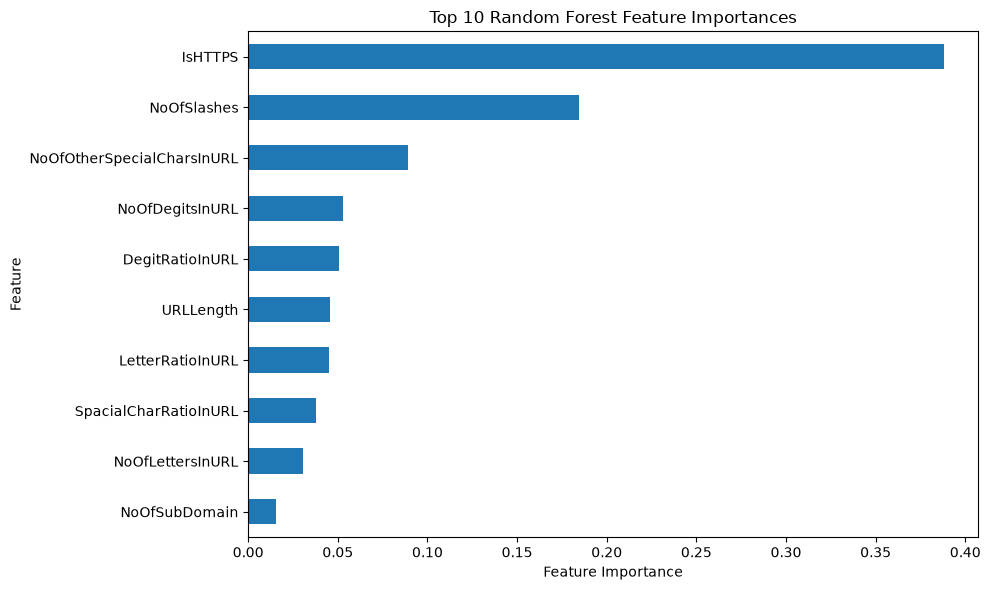

In [ ]:
import matplotlib.pyplot as plt

top_10_features = feature_importance_rf.head(10)

plt.figure(figsize=(10, 6))

top_10_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretation of Random Forest Feature Importance

The Random Forest feature importance analysis shows that `IsHTTPS` is the most
influential feature in the trained model, with an importance of approximately
0.388 (38.8%). It is followed by `NoOfSlashes` at approximately 18.4%.

Other important URL characteristics include the number of special characters,
number and ratio of digits, URL length, letter ratio, special-character ratio,
number of letters, and number of subdomains.

These results indicate that the model does not rely only on a single URL
characteristic. Multiple structural and lexical properties of URLs contribute
to phishing classification.

However, the high importance of `IsHTTPS` must be interpreted carefully.
During dataset analysis, all legitimate URLs in the PhiUSIIL dataset were found
to use HTTPS. Therefore, part of the predictive strength of this feature may
reflect characteristics of the dataset rather than a universal rule that HTTPS
websites are legitimate.

The earlier ablation analysis also showed that the tree-based models maintained
very high performance even when `IsHTTPS` and `NoOfSlashes` were removed.
Therefore, although these features are highly influential, the model also learns
useful patterns from the remaining URL characteristics.

Features receiving zero or very low importance in this Random Forest are not
necessarily universally irrelevant to phishing detection. Their importance
indicates how useful they were to this particular trained model in the presence
of the other available features.

Random Forest feature importance provides global model interpretation by showing
which features influence the model overall. It does not, by itself, explain why
a particular individual URL received a specific prediction.

## Final Model Selection

### Grouped Validation Model Comparison

| Model | Accuracy | Phishing Precision | Phishing Recall | Phishing F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 99.73% | 99.98% | 99.39% | 99.69% |
| Decision Tree | 99.75% | 99.86% | 99.56% | 99.71% |
| Random Forest | 99.79% | 99.94% | 99.57% | 99.76% |

The grouped validation was used for final model comparison because it prevents
the same domain from appearing in both the training and testing sets. This
provides a stricter estimate of generalization to previously unseen domains.

### Why Random Forest Was Selected

Random Forest was selected as the final baseline model for TrustLens based on
multiple factors rather than accuracy alone.

1. It achieved the highest grouped-validation accuracy of approximately 99.79%.

2. It achieved the highest phishing recall among the three evaluated models,
   approximately 99.57%. High phishing recall is particularly important because
   a false negative represents a phishing URL incorrectly classified as
   legitimate.

3. Its training and testing accuracies were very close, indicating no substantial
   overfitting under the grouped validation.

4. As an ensemble of multiple Decision Trees, Random Forest generally provides
   greater stability and reduces the variance associated with relying on a
   single Decision Tree.

5. The earlier ablation analysis showed that the tree-based approach remained
   highly accurate even after removing dominant features such as `IsHTTPS` and
   `NoOfSlashes`, providing evidence that useful information exists across
   multiple URL characteristics.

6. Random Forest provides feature importance scores, which support TrustLens's
   requirement for model-level interpretability.

Therefore, Random Forest provides the best overall balance of predictive
performance, phishing detection capability, robustness, and interpretability
among the three evaluated baseline models.

## Phase 4.5 Validation Conclusion

The mandatory model-validation checkpoint was completed before proceeding to
application development.

The following were verified:

- The dataset and selected URL-based features are suitable for baseline model
  development.
- Preprocessing statistics were learned only from training data to prevent
  data leakage.
- Domain-grouped validation produced zero domain overlap between training and
  testing data.
- Class proportions remained approximately 57.3% legitimate and 42.7% phishing.
- Logistic Regression, Decision Tree, and Random Forest were evaluated using
  accuracy, precision, recall, F1-score, confusion matrices, and train-test
  performance comparisons.
- No substantial overfitting was observed.
- Random Forest achieved the strongest overall grouped-validation performance.
- Feature importance was examined to understand the model's global behavior.
- Dataset-specific limitations, particularly the strong `IsHTTPS` signal, were
  identified and documented.

Based on these results, Random Forest is selected as the final baseline
classifier for TrustLens.

Phase 4 and the mandatory Phase 4.5 validation checkpoint are therefore
complete.